In [9]:
import urllib.parse
import zipfile

with zipfile.ZipFile("../marvel_pages.zip") as z:
    marvel_pages = {
        urllib.parse.unquote(n.split("/")[-1][:-4]): z.read(n).decode("utf-8")
        for n in z.namelist()
        if n.endswith(".txt") and "README" not in n
    }
# marvel_pages: 303 pages, keyed by node_id — set(marvel_pages) == set(nodes.node_id)
marvel_pages["Hulk"]

'The Hulk is a superhero appearing in American comic books published by Marvel Comics. Created by writer Stan Lee and artist Jack Kirby, the character first appeared in the debut issue of The Incredible Hulk (May 1962). In his comic book appearances, the character, who has dissociative identity disorder (DID), is primarily represented by the alter ego Hulk, an immense, green-skinned, hulking brute, possessing a limitless degree of physical strength, and the alter ego Dr. Robert Bruce Banner, a physically weak, socially withdrawn, and emotionally reserved physicist, both of whom typically resent each other. Lee stated that the Hulk\'s creation was inspired by a combination of Frankenstein and Dr. Jekyll and Mr. Hyde.\nFollowing his accidental exposure to gamma rays while saving the life of Rick Jones during the detonation of an experimental bomb, Banner is physically transformed into the Hulk when subjected to emotional stress, at or against his will. This transformation often leads to 

# From Raw Text to Tokens

__Tokenization__ sounds easy, but can be _hard_. What is a _token_?

Computers doesn't process text as we see it; it must convert text to _tokens_; number representations of that _text_. A token is abstract, but at its simplest, it might be the words in a text:

$$ "\text{Iron Man isn't in New York}" \rightarrow ["\text{Iron}"\, "\text{Man}"\, "\text{isn't}"\, "\text{in}"\, "\text{new}"\, "\text{york}"] $$

However, "isn't" may also be split by another tokenizer: "isn't"$\rightarrow$["is", "n't]. And __both are valid__!

__Be aware of modeling choices__; What _is_ a token, is a _choice_; How are punctuations handled? Spaces? Sound Words like umm, um, uhm?

__Word vs Subwords__: most tokenizer work with _subwords_ so "Apple" is split it "Ap" and "_ple". A language model then has the option to work with "Ap" and do either "App" or "Apple" depending on context. 

## Pipeline
$$ \text{raw characters} \rightarrow \text{tokenizer} \rightarrow \text{token pieces} \rightarrow \text{token IDs} \rightarrow \text{Model} $$

So the tokens are converted to _integers_; unique for each token. Some things happen _after_ tokenization. _Stopword removal_ may be one, so removing words like "the", "of" and similar; they do not provide much value in contexts, but are important in sentence constructions of course; is capitalization important? Then "Apple" and "apple" are two different tokens! Then there are considerations about _punctuation_!

We distinct between _types_ and _instances_: A _type_ is the _token_, but no duplicates; _instances_ is the _number of tokens_ of a type. Vocabulary is the _size of set of types_ $|V|$.

In [1]:
import spacy

nlp = spacy.load("en_core_web_sm")  # the whole English pipeline, not just a tokenizer
raw = "Marvel's heroes weren't fighting in New York."
doc = nlp(raw)

print(f"{'Text':>10}: {'Lemma':<10} {'POS':<10} {'Tag':<10} {'Dep':<10} {'Shape':<10} {'Alpha':<5} {'Stop':<5}, Explanation")
for t in doc:
    print(f"{t.text:>10}: {t.lemma_:<10} {t.pos_:<10} {t.tag_:<10} {t.dep_:<10} {t.shape_:<10} {t.is_alpha:<5} {t.is_stop:<5}, {nlp.tokenizer.explain(t.text)}")
# ['Marvel', "'s", 'heroes', 'were', "n't", 'fighting', 'in', 'New', 'York', '.']

lower = [t.text.lower() for t in doc]
no_punct = [t.text for t in doc if not t.is_punct]
no_stop = [t.text for t in doc if not t.is_stop]
lemmas = [t.lemma_ for t in doc]

      Text: Lemma      POS        Tag        Dep        Shape      Alpha Stop , Explanation
    Marvel: Marvel     PROPN      NNP        poss       Xxxxx      1     0    , [('TOKEN', 'Marvel')]
        's: 's         PART       POS        case       'x         0     1    , [('SPECIAL-1', "'s")]
    heroes: hero       NOUN       NNS        nsubj      xxxx       1     0    , [('TOKEN', 'heroes')]
      were: be         AUX        VBD        aux        xxxx       1     1    , [('TOKEN', 'were')]
       n't: not        PART       RB         neg        x'x        0     1    , [('TOKEN', "n't")]
  fighting: fight      VERB       VBG        ROOT       xxxx       1     0    , [('TOKEN', 'fighting')]
        in: in         ADP        IN         prep       xx         1     1    , [('TOKEN', 'in')]
       New: New        PROPN      NNP        compound   Xxx        1     0    , [('TOKEN', 'New')]
      York: York       PROPN      NNP        pobj       Xxxx       1     0    , [('TOKEN', 'York')]
  

### 5.1)
1) The toy next-token generator at the start of the page already assumes that the text has been split into tokens and that a probability table exists for what comes next. In a real system, which part is decided by the tokenizer before the language model sees the text, and which part must the language model learn from training data?
    - The language model must learn the probability distributio/probability table from the training data; the text has already been split beforehand by the tokenizer.

2) Explain the difference between a token, a type, and a vocabulary using a sentence of your own. Then say exactly what can happen to the number of types if you lowercase the sentence.
    - __Token__: A representation of a subset of natural language; could be word, subword, punctuation or several words at once.
    - __Type__: distinct tokens
    - __Vocabulary__: The set of types/distinct tokens.


3) Put these in the right order and explain what each step does: token IDs, raw characters, tokenizer, model, token pieces. Which step decides that New York is two pieces rather than one?
    - _raw characters_ --> _tokenizer_ --> _token pieces_ --> _token IDs_ -->_model_

4) Lowercasing, stopword removal and lemmatization all throw information away. Pick one of them. Give one research question where it would probably be harmless, and one where it could destroy the signal you care about.
    - I pick now _lowercasing_;
        1) Reserach question harmless:    "_Can you give me a semantic analysis of these documents_"?
        2) Research question destructive: "_Can you provide analysis on which words are usually used to open questions_"?

5) This one is about the reading. Jurafsky & Martin (Chapter 2) describe how byte-pair encoding (BPE) builds a subword vocabulary. In your own words, what does BPE start from, what does it repeat, and when does it stop? Why does starting from single characters mean no word is ever completely unknown to the model?
    - BPE starts from single-characters in the corpus; that is also why no word is ever completely unknown to the model, as long as the word is comprised of characters that exists in the corpus. It repeatedly then builds up closes pairs of entries in our vocabulary so far, merging those exactly in the originals afterwards. This way it may build up frequently seen words or character pairs, and leave rare or unseen ones to be built up from single characters.

    It is also worth noting it does not run over punctuation; sentences are processed independetly as a corpus, so no merges happen over "." or "?" etc. A character for space is usally added, for example "_"


### 5.2)
1) Start with "Spider-Man didn't save Queens; Doctor Strange's portal did!" Before you split anything, write down your rules: what happens to hyphens, apostrophes and punctuation? Then tokenize the sentence by hand and report the number of tokens and types. Keep your answer, because you will check it against spaCy in 5.3.
    - Keep hypthens, but as singular character; split apostrophes such that it is between exactly 2 characters. Keep punctuation, but singular
    - __Tokenization__: ["Spider", "-", "Man", "did", "n't", "save", "Queens", ";", "Doctor", "Strang", "e's", "protal", "did", "!"]

2) Now predict, without running code, what happens to the token and type counts after lowercasing and after removing punctuation. Then define a small stopword set of your own, remove it, and predict the counts again. Some counts may stay the same. Say why.
    - Lowercasing will not do anything, as we have no words, according to my tokenizer, that would be the same after lowercasing anyways. Removing punctuation would change a few things: removes ";", "-" and "!", which in turns means that "Stranges" and "SpiderMan" and "didn't" are now in the tokens. A stop word I would define is "didn't" and "did". It removes exactly those two occurances.

3) New York remaining as two tokens is not a tokenizer failure. What later NLP task could decide that the two tokens together refer to one place? Give one more example where token boundaries and the thing we care about are not the same.
    - Usually we tokenize the space between it with it; "_York" it would be. This illustrates that there is a space. It is the training of the distribution that is accountable for learning that when we speak of "New" we most likely also speak of "York".

4) Now play subword tokenizer. Your whole vocabulary is the pieces "_un, believ, able, spider, man, hat, tan, wak, anda_", plus every single letter. Lowercase each word, then split it from left to right, always taking the longest piece in the vocabulary that fits. Segment _unbelievable, Spiderman, Wakanda, Manhattan and Thanos_. Which word costs the most tokens, and why is that still better than having no representation for it at all?
    - ["un", "believ", "able", "spider", "man", "wak", "anda", "man", "hat", "tan", "t", "h", "a", "n", "o", "s"].
    - It is still better, because otherwise we would not have that representation at all!

5) Suppose your question is whether the word power is used differently across two Marvel communities. Would you lowercase? Lemmatize? Remove stopwords? There is no universal answer here. Make the choices you would use and defend them. Careful with the last one: if you compare how often power occurs relative to the total number of tokens, does removing stopwords change that number even though no power token was removed?
    - Lowercasing may remove times when "power" is used in emphasis like "POWER", so I would refrain from using lower casing. Removing stop words may help semantically, but it can reduce the frequency analysis of the word.

In [10]:
test_ = "Spider-Man didn't save Queens; Doctor Strange's portal did!"
from collections import Counter

from tiktoken import get_encoding

encoder = get_encoding("o200k_base")
encoded = encoder.encode(test_)

#Through SpaCy
doc2 = nlp(test_)

print([encoder.decode([i]) for i in encoded])
print([t.text for t in doc2])
print("o200k encoder respects spaces, while SpaCy does not.")
print("SpaCy also did splits on apostrophes and hyphens, while o200k did not.")

# Try on one of the Marvel Pages
hulk_encoded = encoder.encode(marvel_pages["Hulk"])

print("Raw character count: ", len(marvel_pages["Hulk"]))
print("Number of tokens in Hulk's text:", len(hulk_encoded))

freqs = Counter([encoder.decode([i]) for i in hulk_encoded])
freqs.most_common(10)  # most common tokens in Hulk's text


['Spider', '-Man', " didn't", ' save', ' Queens', ';', ' Doctor', ' Strange', "'s", ' portal', ' did', '!']
['Spider', '-', 'Man', 'did', "n't", 'save', 'Queens', ';', 'Doctor', 'Strange', "'s", 'portal', 'did', '!']
o200k encoder respects spaces, while SpaCy does not.
SpaCy also did splits on apostrophes and hyphens, while o200k did not.
Raw character count:  46288
Number of tokens in Hulk's text: 9735


[(' the', 467),
 (',', 412),
 (' Hulk', 266),
 ('.', 260),
 (' and', 240),
 (' to', 195),
 (' of', 171),
 (' a', 141),
 (' in', 131),
 (' ', 125)]

# 3) Counting Language, the Old-School Way



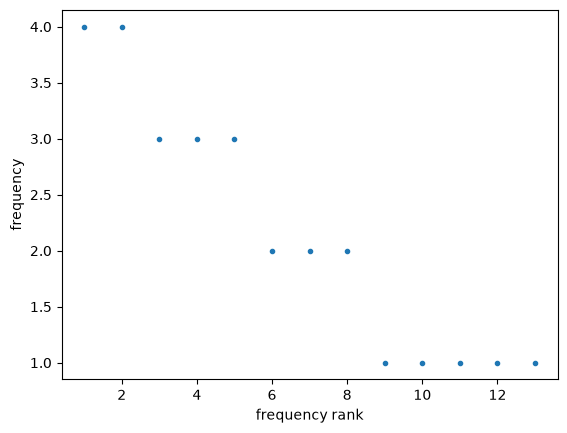

th ym ion flat the i then ic ord is ing ains nd ling star entry pool
ena ak ole


In [18]:
import matplotlib.pyplot as plt
from nltk import FreqDist
from nltk.text import Text

# All marvel pages combined and then tokenized:
marvel_text = " ".join(marvel_pages.values())
marvel_tokens = [encoder.decode([token]) for token in encoder.encode(marvel_text)]

tokens = [
    "iron", "man", "fights", "the", "villain", ".",
    "the", "villain", "escapes", "to", "new", "york", ".",
    "iron", "man", "follows", "the", "villain", "to", "new", "york", ".",
    "the", "city", "thanks", "iron", "man", "."
]

len(tokens)

counts = Counter(tokens)
# counts.most_common(10)

n_tokens = len(tokens)
n_types = len(counts)
n_hapax = sum(n == 1 for n in counts.values())

# n_tokens, n_types, n_hapax

total = len(tokens)
relative_frequency = {
    word: count / total
    for word, count in counts.items()
}

fd = FreqDist(tokens)
fd.most_common(10)
fd.hapaxes()[:10]

frequencies = sorted(counts.values(), reverse=True)
ranks = range(1, len(frequencies) + 1)

plt.plot(ranks, frequencies, ".")
plt.xlabel("frequency rank")
plt.ylabel("frequency")
plt.show()

marvel = Text(marvel_tokens)

# marvel.concordance("power")
marvel.similar("rock")
# marvel.common_contexts(["power", "strength"])

### 5.4) Is Marvel Zipf-like
1) 🧠 Look at the idealized Zipf curve and the Marvel-description curve before writing any code. Write down two reasons why the observed Marvel curve might deviate from the idealized one. Make one prediction about what will happen when you switch from the short descriptions to the full Wikipedia pages.
    - I predict that adding the full pages will make it conform more to be a line on the loglog axis view; I suspect the 303 page summaries are lacking in sample size. Moby Dick is a long novel, and the language may be more diverse than in the summaries.

2) Load the full raw Marvel pages from the course data page. Under one clearly stated preprocessing choice, report the total number of tokens, number of types, number of hapax types, and the ten most frequent token types.

3) Plot frequency against rank on both linear and log-log axes. Put the full-page result next to the short-description result and the idealized curve. Does the larger corpus look more Zipf-like? Go back to the explanations from item 1 and say which still look plausible.

4) 🧠 A straight-ish line on log-log axes is tempting. Is that plot alone enough to conclude that the corpus follows Zipf's law? Say what the figure supports, what it does not establish, and what else you would want to check before making a stronger claim.

5) 🧠 Think beyond Marvel. Name one corpus you expect to look more Zipf-like and one you expect to look less Zipf-like. Explain why. If either corpus is easy to get, test your prediction. One easy place to start: NLTK ships a small sample of Project Gutenberg books (nltk.corpus.gutenberg), including Moby Dick as melville-moby_dick.txt, so you can check Lestrade's example yourself.

# 4) From Words to Documents

We have worked the _LLM_ way; in streams of tokens. __Old schoold NLP__ is still useful in some regards, and that is the focus here.

__Document__: Can be a webpage, a speech and a book; all examples of _documents_. We want to start simple.

__Bag of Words__: turning the document to numbers. Often done in a _document-word matrix_ $X$.
- _Rows_: documents
- _Columns_: vocabulary term.  

The entry at $X_{dt}$ is the number of times term $t$ appears in document $d$. Below is a worked example:

1) __Documents__:
    1) "brains predict the future brains"
    2) "models predict the future"
    3) "brains build models"
2) __Tokenize__: tokenize each document
    1) [brains] [predict] [the] [future] [brains]
    2) [models] [predict] [the] [future]
    3) [brains] [build] [models]
3) __Vocabulary__: all unique tokens amongst the documents
    - brains · build · future · models · predict · the
4) __Count__ each term for each document
    1) brains 2 · build 0 · future 1 · models 0 · predict 1 · the 1
    2) brains 0 · build 0 · future 1 · models 1 · predict 1 · the 1
    3) brains 1 · build 1 · future 0 · models 1 · predict 0 · the 0
5) __Encode__ each into a vector
    1) $[2, 0, 1, 0, 1, 1]$
    2) $[1, 1, 1, 1, 0, 0]$
    3) $[1, 1, 0, 1, 0, 0]$
6) __Document-Term Matrix__ formation:
    - $ \begin{bmatrix} 2 & 0 & 1 & 0 & 1 & 1 \\ 1 & 1 & 1 & 1 & 0 & 0 \\ 1 & 1 & 0 & 1 & 0 & 0\end{bmatrix} $

While neat, as we can do a lot of stuff with the matrix, we have _lost the order of the words_. We see the above in code below: 

In [2]:
from sklearn.feature_extraction.text import CountVectorizer

documents = [
    "brains predict the future brains",
    "models predict the future",
    "brains build models"
]

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(documents)

print(vectorizer.get_feature_names_out())
print(X.toarray())

['brains' 'build' 'future' 'models' 'predict' 'the']
[[2 0 1 0 1 1]
 [0 0 1 1 1 1]
 [1 1 0 1 0 0]]


It may happen that these will be very __sparse matrices__, because we may have a lot of unique words, that only occur a few times among many documents. Depending on the choice of tokenizer; stop-words, capitalization, punctuation et cetera, the shape and content of the matrix changes.

### 5.6) Bag of Words
No library for this one. If you can build the tiny matrix yourself, the large one stops being mysterious.
1) Use the three documents 1) "_Thor fights the X-Men._", 2) "_The X-Men fight back._" and 3) "_Thor and Loki fight and fight_.". Lowercase everything, drop the punctuation, and keep X-Men as one word. Alphabetize the vocabulary, write the three document vectors, and stack them into the document-term matrix.
    - ['and' 'back', 'fight', 'fights', 'loki', 'the', 'thor', 'x-men']
    1) [0, 0, 0, 1, 0, 1, 1, 1]
    2) [0, 1, 1, 0, 0, 1, 0, 1]
    3) [2, 0, 2, 0, 1, 0, 1, 0]
2) Read the matrix in both directions. Which terms do Documents 1 and 2 share? Which terms connect Document 3 to the other two? Pick the column for fight and explain what every number in that column means. Why do fight and fights get separate columns, and which preprocessing step from Section 2 would merge them?
    1) Documents 1 and 2 share "the" and "x-men".
    2) Document 3 has no single part that connects to both
    3) Document 2 has one mention of "fight", whereas document 3 has two mentions.
    4) Fight and fights get seperate columns, because they are both tokenized differently, and thus get different types; _lemmazation_ would merge them as both would tokenize to "fight" then.
3) Change one document so that a word already in the vocabulary appears one more time, and another so that it contains a brand-new word. Predict exactly which cells change, and what happens to the shape of the matrix, before you recalculate it.
    1) Say we add "The" in front of Thor in document 1; this would change the "1" in column 6 to a "2".
    2) Say we add the word "on" at the end of document 3; in this case, a new column for "on" is added which sits between "loki" and "the", and it would have a "0" for document (row) 1 and 2, but a "1" at row 3.
    3) The shape then becomes $3\times 9$.
4) Give one research question where losing word order is probably acceptable and one where it would make the representation close to useless.
    - "Who fights who?"


In [6]:
# 5.7 — Bag of Words on Marvel, as code

# First part, recreation of above:
from sklearn.feature_extraction.text import CountVectorizer

documents = [
    "Thor fights the X-Men.",
    "The X-Men fight back.",
    "Thor and Loki fight and fight on."
]

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(documents)

print(vectorizer.get_feature_names_out())
print(X.toarray())

['and' 'back' 'fight' 'fights' 'loki' 'men' 'on' 'the' 'thor']
[[0 0 0 1 0 1 0 1 1]
 [0 1 1 0 0 1 0 1 0]
 [2 0 2 0 1 0 1 0 1]]


# 5) Where counting stops

With the above document-term matrix, we have a lot of information already. We can go a bit further here.

__Which pages look alike?__ A standard measure is cosine similarity:
$$ \cos(x, y) = \frac{x\cdot y}{||x||\,||y||}, $$
where a values of "1" means exactly the same direction, and 0 is perpendicular (no shared terms). If we remove stop-words, it can give a good idea of identical terms that appear in two documents, and thus may be sharing similar themes.

__Word vectors__: in _Bag-of-Words_, each word gets its own column. However, no terms in that way can say anything about how they relate to one another; "Dog" and "Empire" has as much in common as "Dog" and "Puppy"; but _we know_ that dog and puppy are quite related in semantics, more so than "dog" and "Empire" at least.

__Beyond the counts__: N-grams were fine for local order, but it had a problem when $n$ was large; exact sequences became too rare. A 5-gram may provide good context, but only seen once in a corpus. This is the stuff for next week; probably _word embeddings_. 